# **Homework 2**
## ECEN 5156 - Physical Optics
### *Samuel Arnold*
### *9/17/26*
***

## 0.) Fresnel Rhomb

### 0.a)

The reflectance coefficients when above the critical angle for internal reflection are complex and represented by:

$$r_{TE} = \frac{\cos \theta_I - i \sqrt{\sin^2 \theta_I - n^2}}{\cos \theta_I + i \sqrt{\sin^2 \theta_I - n^2}} \tag{1}$$

$$r_{TM} = \frac{-n^2 \cos \theta_I + i \sqrt{\sin^2 \theta_I - n^2}}{n^2 \cos \theta_I + i \sqrt{\sin^2 \theta_I - n^2}} \tag{2}$$

When written in polar form:
$$r = |r| e^{i\phi} \tag{3}$$

When applied to Equations 1 the resulting equation is:

$$r_{TE} = \frac{e^{-i\alpha}}{e^{i\alpha}} = e^{-i(2\alpha)} \tag{4}$$

with:

$$\tan \alpha = \tan \left(-\frac{\phi_{TE}}{2}\right) = \frac{\sqrt{\sin^2 \theta_I - n^2}}{\cos \theta_I}$$

resulting in:

$$\phi_{TE} = -2 \tan^{-1} \left(\frac{\sqrt{\sin^2 \theta_I - n^2}}{\cos \theta_I} \right)$$

and

$$\phi_{TM} = -2 \tan^{-1} \left(\frac{\sqrt{\sin^2 \theta_I - n^2}}{n^2 \cos \theta_I} \right) + \pi$$

therefore

$$\Delta \phi = \phi_{TM} - \phi_{TE} = 2 \tan^{-1} \left(\frac{\cos \theta_I \sqrt{\sin^2 \theta_I - n^2}}{\sin^2 \theta_I} \right)$$

with $\Delta \phi = 45^{\circ} = \frac{3\pi}{4}$ (starting from $\pi$)

$$\theta  \approx 50.3, 53.2^{\circ}$$

The two crossing angles are approximately: [50.3, 53.2] degrees


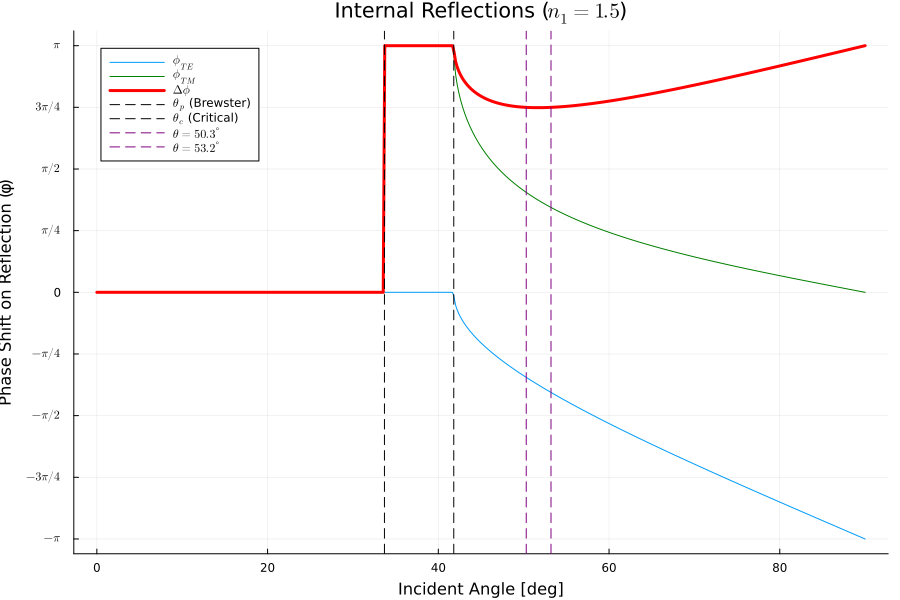

In [72]:
using Plots

gr()

default(size=(900, 600))

n1 = 1.5
n2 = 1.0

theta_range = range(0, 90, length=500)
theta_rad = deg2rad.(theta_range)

n = n2/n1

theta_c = asin(n)
theta_c_deg = rad2deg(theta_c)
theta_p = atan(n)
theta_p_deg = rad2deg(theta_p)

function phase_calc_TE(theta_rad, n, theta_c)
    if theta_rad >= theta_c
        return -2 * atan(sqrt(sin(theta_rad)^2 - n^2) / cos(theta_rad))
    else
        return(0.0)
    end
end

function phase_calc_TM(theta_rad, n, theta_c, theta_p)
    if theta_rad <= theta_p
        return(0.0)
    elseif theta_p <= theta_rad <= theta_c
        return pi
    else
        return -2 * atan(sqrt(sin(theta_rad)^2 - n^2) / (n^2 * cos(theta_rad))) + pi
    end
end

phi_TE = phase_calc_TE.(theta_rad, n, theta_c)
phi_TM = phase_calc_TM.(theta_rad, n, theta_c, theta_p)

delta_phi = phi_TM - phi_TE


crossing_angles = findall(i -> theta_range[i] > 41.8 && abs(delta_phi[i] - 3*pi/4) < 0.00056, 1:length(delta_phi))

println("The two crossing angles are approximately: ", round.(theta_range[crossing_angles], digits=1), " degrees")

radian_ticks = ([0, pi/4, pi/2, 3*pi/4, pi, -pi/4, -pi/2, -3*pi/4, -pi], ["0", raw"$\pi/4$", raw"$\pi/2$", raw"$3\pi/4$", raw"$\pi$", raw"$-\pi/4$", raw"$-\pi/2$", raw"$-3\pi/4$", raw"$-\pi$"])

plot(
    theta_range,
    phi_TE,
    label = raw"$\phi_{TE}$",
    xlabel="Incident Angle [deg]",
    ylabel=raw"Phase Shift on Reflection (\phi)",
    title=raw"Internal Reflections ($n_1 = 1.5$)",
    yticks = radian_ticks,
)

plot!(
    theta_range,
    phi_TM,
    label = raw"$\phi_{TM}$",
    color=:green
)

plot!(
    theta_range,
    delta_phi,
    label = raw"$\Delta \phi$",
    color=:red,
    lw=3
)

vline!(
    [theta_p_deg], 
    label = raw"$\theta_p$ (Brewster)", 
    line = (:black, :dash, 1)
)
vline!(
    [theta_c_deg], 
    label = raw"$\theta_c$ (Critical)", 
    line = (:black, :dash, 1)
)
vline!(
    [50.3], 
    label = raw"$\theta = 50.3^{\circ}$", 
    line = (:purple, :dash, 1)
)
vline!(
    [53.2], 
    label = raw"$\theta = 53.2^{\circ}$", 
    line = (:purple, :dash, 1)
)

### 0.b)

The internal angle as shown in the figure provided would have to be either of the two angles listed in 0.a such that two sucessive ($-\frac{3\pi}{4}$) phase shifts results in $2(-\frac{3\pi}{4}) = -\frac{3\pi}{2}$ or $+\frac{\pi}{2}$. Which acts like the quarter wave retarder and changes linearly polarized light to circularly polarized.

### 0.c)


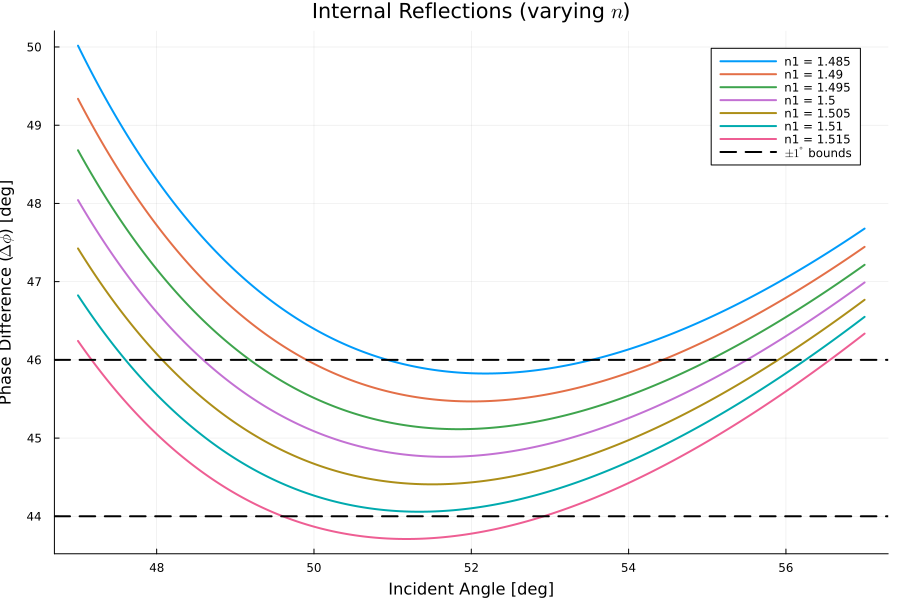

In [105]:
using Plots

gr()

default(size=(900, 600))

n1_list = [1.485, 1.490, 1.495, 1.500, 1.505, 1.510, 1.515]
n2 = 1.0

theta_range = range(47, 57, length=500)
theta_rad = deg2rad.(theta_range)




function phase_calc_TE(theta_rad, n, theta_c)
    if theta_rad >= theta_c
        return -2 * atan(sqrt(sin(theta_rad)^2 - n^2) / cos(theta_rad))
    else
        return(0.0)
    end
end

function phase_calc_TM(theta_rad, n, theta_c, theta_p)
    if theta_rad <= theta_p
        return(0.0)
    elseif theta_p <= theta_rad <= theta_c
        return pi
    else
        return -2 * atan(sqrt(sin(theta_rad)^2 - n^2) / (n^2 * cos(theta_rad))) + pi
    end
end

offset_ticks = ([134, 135, 136, 137, 138, 139, 140], [44, 45, 46, 47, 48, 49, 50])

plot(
    xlabel="Incident Angle [deg]",
    ylabel=raw"Phase Difference ($\Delta\phi$) [deg]",
    title=raw"Internal Reflections (varying $n$)",
    yticks = offset_ticks,
)

for n1 in n1_list
    n = n2 / n1
    theta_c = asin(n)
    theta_p = atan(n)
    
    phi_TE = phase_calc_TE.(theta_rad, n, theta_c)
    phi_TM = phase_calc_TM.(theta_rad, n, theta_c, theta_p)
    delta_phi = phi_TM - phi_TE

    delta_phi_deg = rad2deg.(delta_phi)
    
    # Plot just the Delta Phi curve for this specific n1
    plot!(
        theta_range, 
        delta_phi_deg, 
        label = "n1 = $n1", 
        lw = 2
    )
end

hline!(
    [134],
    line = (:black, :dash, 2),
    label = raw"$\pm 1^{\circ}$ bounds"
)

hline!(
    [136],
    line = (:black, :dash, 2),
    label = ""
)

current()



It looks like an index of $n \approx 1.51$ provides the widest incident angle range that still crosses the target $45^{\circ}$ center phase difference and falls within the $\pm 1^{\circ}$ bounds.

### 0.d)

Using:

$$\Delta \phi = \phi_{TM} - \phi_{TE} = 2 \tan^{-1} \left(\frac{\cos \theta_I \sqrt{\sin^2 \theta_I - n^2}}{\sin^2 \theta_I} \right)$$

and solving for $n$ while $\theta = 45^{\circ}$

$$\tan(\frac{\Delta \phi}{2}) \sin^2(\theta) = \cos \theta_I \sqrt{\sin^2 \theta_I - n^2}$$
$$\left(\frac{\tan(\frac{\Delta \phi}{2}) \sin^2(\theta)}{\cos \theta_I }\right)^2 = \sin^2 \theta_I - n^2$$
$$n = \sqrt{\sin^2 \theta_I - \left(\frac{\tan(\frac{\Delta \phi}{2}) \sin^2(\theta)}{\cos \theta_I }\right)^2}$$

In [116]:
n_45 = sqrt(sin(pi/4)^2 - ((tan(pi/8)*sin(pi/4)^2)/(cos(pi/4)))^2)

n_rel = 1/n_45

println("The index to achive a 45 degree phase shift upon TIR at a 45 degree angle is: ", round(n_rel, digits = 3))

The index to achive a 45 degree phase shift upon TIR at a 45 degree angle is: 1.554


***

## 1.) Reflection and Polarization

### 1a.) $n_1 > n_2$ and normal incidence

$$r_{TE} = \frac{\cos \theta_I - n \cos \theta_T}{\cos \theta_I + n \cos \theta_T}$$

$$r_{TM} = \frac{-n\cos \theta_I + \cos \theta_T}{n\cos \theta_I + \cos \theta_T}$$

At normal incidence all the $\cos \theta$ becomes 1:

$$r_{TE} = \frac{1 - n}{1 + n}$$

$$r_{TM} = \frac{-n + 1}{n + 1}$$

with $n = n_2 /n_1$

$$r_{TE} = \frac{n_1 - n_2}{n_1 + n_2}$$

$$r_{TM} = \frac{n_1 - n_2}{n_2 + n_1}$$


$$r_{TE} \approx \frac{n_1}{n_1 + n_2}$$

$$r_{TM} \approx \frac{n_1}{n_2 + n_1}$$

With the reflection coeffecients for both sharing the same magnitude, there is no phase change in between them. As a result, the light stays circularly polarized, however the direction changes, which causes a flip in the handedness to LCP.

### 1c.) Incident at Brewster's Angle

At Brewster's angle, the reflectivity of the TM component goes to zero, but the TE component remains. The removal of the TM component just leaves a single part of the circularly polarized light, which is linear. As a result, the outgoing reflected wave is linearly polarized with the TE component.

### 1b.) $n_2 > n_1$ and normal incidence

$$r_{TE} = \frac{- n_2}{n_1 + n_2}$$

$$r_{TM} = \frac{- n_2}{n_2 + n_1}$$

Again, there is no relative phase change between the two, so the polarization remains circular, but the direction changes again, so LCP.

### 1d.) $n_1 > n_2$ and $\frac{n_1}{n_2}\sin \theta_I > 1$

Again with $n_1 > n_2$, the components are equal in magntitude.

$$r_{TE} \approx \frac{n_1}{n_1 + n_2}$$

$$r_{TM} \approx \frac{n_1}{n_2 + n_1}$$

However, the angle bounds provided are characteristic for total internal reflection (it's a rewritten form of Snell's law with $\sin(90)=1$), meaning they undergo different phase shifts (see previous question). This causes elliptical polarization.

***

## 2.) Two layer antireflection coatings

### 2a.)

$$R = \frac{(1-n)^2 (\Delta \lambda / \lambda_0)}{4n}$$

$$\frac{\delta}{2} \approx \frac{\pi}{2} (1-\frac{\Delta \lambda}{\lambda_0})$$

### I don't think we finished the material to solve this, last thing I have from Thursday is the Reflectance equation and that was single layer. 

***
## 4.) General 3-layer Problem for TE Wave

### 4.d)

$$\lambda_0 = 633 \text{ nm, } n_1 = n_3 = 1.55 \text{, } n_2 = 1.0 \text{, } \theta_1 = 55^{\circ}$$

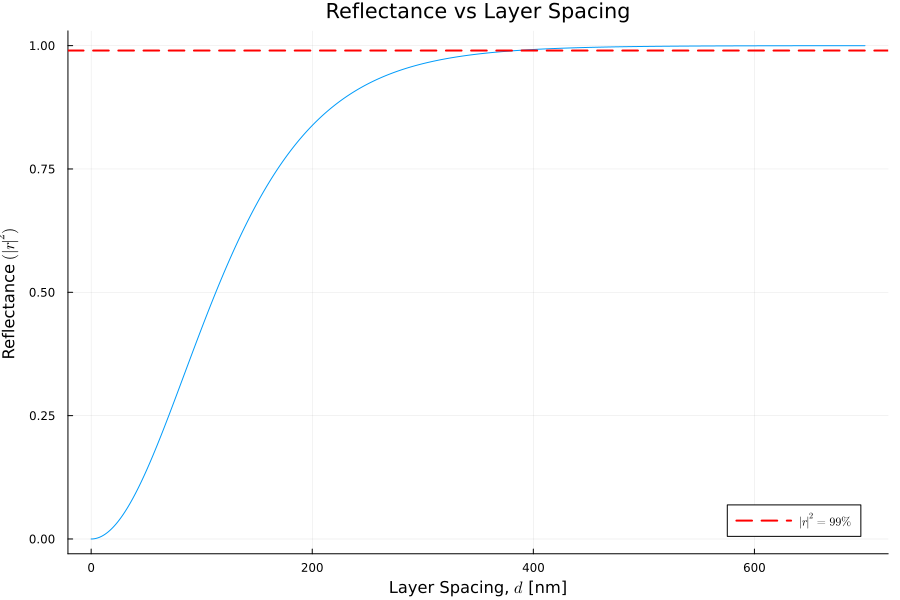

In [126]:
using Plots

gr()

default(size=(900, 600))

n1 = 1.55
n2 = 1.0
n3 = n1

lambda = 633
k_vec = 2*pi / lambda

theta_1 = 55
theta_1_rad = deg2rad(theta_1)

k_y = n1 * k_vec * sin(theta_1_rad)
k_x = n1 * k_vec * cos(theta_1_rad)
p_x = k_x       #n3 = n1

d_range = range(0, 700, length=500)

gamma = sqrt(k_y^2 - (n2 * k_vec)^2)
qx = 1im * gamma 


function reflectance_calc(d)
    B = ((qx - p_x) / (qx + p_x)) * exp(2im * qx * d)
    ratio = (qx / k_x) * ((1 - B) / (1 + B))
    r_s = (1 - ratio) / (1 + ratio)
    return abs2(r_s)
end

R = reflectance_calc.(d_range)

plot(
    d_range,
    R,
    xlabel=raw"Layer Spacing, $d$ [nm]",
    ylabel=raw"Reflectance $(|r|^2)$",
    title=raw"Reflectance vs Layer Spacing",
    label=""
)


hline!(
    [0.99],
    line = (:red, :dash, 2),
    label = raw"$|r|^2= 99\%$"
)

current()



Between 0 and $\approx 375$ nm, in spacing of the layers, the reflectance has values that are not 1. While its expected that total internal reflection occurs (R=1), in this short gap of the layers there are portions of the wave that are able to transmit through the boundary. This is due to the evanescent wave behavior that allows the wave to penetrate through a medium, and if the gap is sufficiently small enough, a portion will be able to pass through and not get reflected.

### 4.e)

An analogy can be drawn to the process of quantum tunneling through a finite potential barrier. When a wavefunction is at a boundary, it can reflect or transmit. At a finite potential interface, the wavefunction decays with a $1/e$ relation through the barrier, and if the barrier is sufficiently small in width, a corresponding wavefunction could be transmitted through the other side.

$$\psi_{barrier} = Ce^{-\beta x}$$
$$\psi_{T} = Fe^{ikx} + Ge^{-ikx}$$

## 5.) Propagation matrices

### Again, don't think we covered enough material to solve this? Looked at recorded lecture and it started this material, but that was for Sep. 22?

## 6.) High reflectivity dielectric mirrors

### Didn't have time to start this, but not confident that we covered enough for this? Maybe we have, just didn't have time to look in depth on this one, sorry.